In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

In [5]:
train = pd.read_csv("C:/Users/VAISHNAVINA/Desktop/XGBOOST/heart.csv")
print(train.shape)

(297, 14)


In [6]:
train.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [7]:
NAs=pd.concat([train.isnull().sum()],axis=1,keys=["Train"])
NAs[NAs.sum(axis=1) > 0]

,Train


In [8]:
train.isnull().sum().sum()

np.int64(0)

In [9]:
categorical_cols = ['cp', 'restecg', 'slope', 'ca', 'thal']

train_encoded = pd.get_dummies(train, columns=categorical_cols, drop_first=True)


In [10]:
print(train_encoded.shape)
print(train_encoded.head())


(297, 21)
   age  sex  trestbps  chol  fbs  thalach  exang  oldpeak  condition   cp_1  \
0   69    1       160   234    1      131      0      0.1          0  False   
1   69    0       140   239    0      151      0      1.8          0  False   
2   66    0       150   226    0      114      0      2.6          0  False   
3   65    1       138   282    1      174      0      1.4          1  False   
4   64    1       110   211    0      144      1      1.8          0  False   

   ...   cp_3  restecg_1  restecg_2  slope_1  slope_2   ca_1   ca_2   ca_3  \
0  ...  False      False       True     True    False   True  False  False   
1  ...  False      False      False    False    False  False   True  False   
2  ...  False      False      False    False     True  False  False  False   
3  ...  False      False       True     True    False   True  False  False   
4  ...  False      False       True     True    False  False  False  False   

   thal_1  thal_2  
0   False   False  
1   Fa

In [11]:
train['condition'].unique()

array([0, 1])

In [12]:
X = train.drop('condition', axis=1)
y = train['condition']


In [13]:
X = pd.get_dummies(X)

In [14]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target distribution:\n", y.value_counts())


X shape: (297, 13)
y shape: (297,)
Target distribution:
 condition
0    160
1    137
Name: count, dtype: int64


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [18]:
rf = RandomForestClassifier(
    n_estimators=100,      # number of trees
    max_depth=None,        # let trees expand fully
    random_state=42,
    n_jobs=-1              # use all CPU cores
)

In [19]:
rf.fit(X_train, y_train)

RandomForestClassifier(n_jobs=-1, random_state=42)

In [20]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8833333333333333

Confusion Matrix:
 [[31  1]
 [ 6 22]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.97      0.90        32
           1       0.96      0.79      0.86        28

    accuracy                           0.88        60
   macro avg       0.90      0.88      0.88        60
weighted avg       0.89      0.88      0.88        60



In [21]:
from sklearn.metrics import roc_curve,auc
false_positive_rate, true_positive_rate,threshold = roc_curve(y_test,y_pred)
roc_auc= auc(false_positive_rate, true_positive_rate)
roc_auc

np.float64(0.8772321428571428)

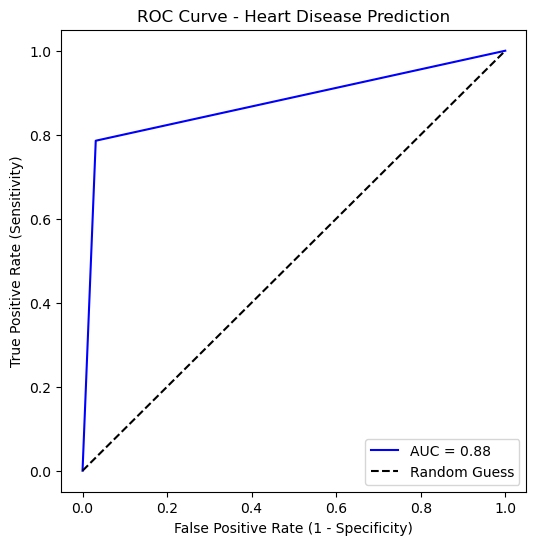

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.plot(false_positive_rate, true_positive_rate, color='blue', label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'k--', label='Random Guess')
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve - Heart Disease Prediction")
plt.legend(loc="lower right")
plt.show()


In [23]:
import joblib
joblib.dump(rf, 'heart_disease_model.pkl')


['heart_disease_model.pkl']